In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
dataset_name = "MNIST"
num_classes = 10
indices = [i for i in range(12)]

In [4]:
data_path = f"../Data/Class_Specific_B_F/MNIST/Base_Fine_Tuned/Entire_Transformation_Matrix_W"
all_classes_name = "Standard_48000_Results_All_Classes.json"

In [5]:
results = []

for filename in os.listdir(data_path):
    if filename in [".DS_Store", all_classes_name]:
        continue
    file_path = os.path.join(data_path, filename)
    if os.path.isfile(file_path):
        results.append(file_path)

print(len(results))

10


In [6]:
data = pd.read_json(os.path.join(data_path, all_classes_name))

In [9]:
task_matrix = [np.array(data["W"][i]) for i in indices]

In [12]:
print(task_matrix[0].shape)

(768, 768)


In [16]:
U = {}
S = {}
Vh = {}

for i in indices:
    U[i] = []
    S[i] = []
    Vh[i] = []
    for j in task_matrix:
        u, s, vh = np.linalg.svd(j)
        U[i].append(np.array(u))
        S[i].append(np.array(s))
        Vh[i].append(np.array(vh))

k for 95% energy: 19


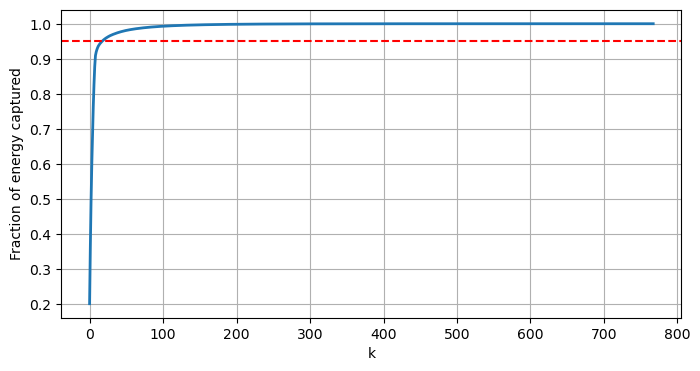

In [17]:
energy = S[11][6]**2
cumulative = np.cumsum(energy)
total = cumulative[-1]
frac = cumulative / total  # fraction of Frobenius energy captured

# Pick k for a threshold
threshold = 0.95
k = np.searchsorted(frac, threshold) + 1  # +1 because searchsorted returns idx
print("k for {:.0%} energy:".format(threshold), k)

import matplotlib.pyplot as plt
# Plot fraction
plt.figure(figsize=(8,4))
plt.plot(frac, linewidth=2)
plt.axhline(threshold, color='red', linestyle='--')
plt.xlabel('k')
plt.ylabel('Fraction of energy captured')
plt.grid(True)
plt.show()

In [ ]:
sorted_files = sorted(results, key=lambda f: f.rsplit('.', 1)[0][-1]) # Sorts by Label

In [ ]:
data = [pd.read_json(i) for i in sorted_files]
all_classes_data = pd.read_json(f"{data_path}/{all_classes_name}")

In [ ]:
task_matrix_class_specific = [] # Nested loop. First list contains the sublists of the specific class's task matrixes. The nested lists keep the task matrixes across the layers of CLIP. 
# task_matrix[0] would access the nested list containing the 12 task matrixes
# task_matrix[0][0] would access the task matrix for the first class at layer 0 
 
for i in range(len(data)):
    task_matrix_class_specific.append([])
    for j in indices:
        task_matrix_class_specific[i].append(np.array(data[i]["W"][j]))

In [8]:
task_matrix_all_classes = [np.array(all_classes_data["W"][i]) for i in indices]

NameError: name 'all_classes_data' is not defined